# Exploración de datos reales de Waymo Open Dataset v2

Este notebook explora los datos reales descargados desde el bucket público de
Waymo Open Dataset v2, para contrastarlos contra el CSV sintético
(`detecciones_crudas`) usado en `01_exploracion_csv.ipynb`.

Seleccionamos 4 segmentos de conducción a propósito para maximizar el
contraste en clima, momento del día y ubicación:

| segment_id (abreviado) | weather | time_of_day | location |
|---|---|---|---|
| `10206293520369375008...` | sunny | Night | location_phx |
| `11017034898130016754...` | sunny | Dawn/Dusk | location_other |
| `6791933003490312185...` | rain | Dawn/Dusk | location_phx |
| `10023947602400723454...` | sunny | Day | location_sf |

`weather`, `time_of_day` y `location` no vienen en los archivos `lidar_box` ni
`camera_to_lidar_box_association` que descargamos: son metadato del segmento
completo (componente `stats` de Waymo, que no descargamos) y quedan
documentados acá a partir de la exploración hecha en Colab. Los usamos solo
para etiquetar los 4 segmentos, no se derivan de estos archivos.

Este notebook no depende del catálogo de Kedro: todas las rutas son relativas
desde `notebooks/` hacia `data/`, para poder correrlo tanto con
`kedro jupyter notebook` como con un Jupyter estándar.

In [1]:
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Metadato de los 4 segmentos, documentado desde la exploración en Colab.
# No se puede derivar de lidar_box ni de camera_to_lidar_box_association:
# esos archivos no traen weather, time_of_day ni location.
METADATA_SEGMENTOS = {
    "10206293520369375008_2796_800_2816_800": {
        "weather": "sunny", "time_of_day": "Night", "location": "location_phx",
    },
    "11017034898130016754_697_830_717_830": {
        "weather": "sunny", "time_of_day": "Dawn/Dusk", "location": "location_other",
    },
    "6791933003490312185_2607_000_2627_000": {
        "weather": "rain", "time_of_day": "Dawn/Dusk", "location": "location_phx",
    },
    "10023947602400723454_1120_000_1140_000": {
        "weather": "sunny", "time_of_day": "Day", "location": "location_sf",
    },
}

RUTA_LIDAR_BOX = Path("../data/01_raw/waymo/lidar_box")
RUTA_ASOCIACION = Path("../data/01_raw/waymo/camera_to_lidar_box_association")
RUTA_CSV_SINTETICO = Path("../data/01_raw/detecciones_waymo_like.csv")

# Paleta categórica fija, misma que en 01_exploracion_csv.ipynb
CAT = {"VEHICLE": "#2a78d6", "PEDESTRIAN": "#eb6834", "CYCLIST": "#1baf7a", "SIGN": "#eda100"}
SURFACE, INK_PRIMARY, INK_SECONDARY, GRID_COLOR, BASELINE = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7",
)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY, "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.titleweight": "bold",
})


def style_ax(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    return ax

## 1. Carga y estructura

Descubrimos los archivos de `lidar_box` dinámicamente con `glob`, sin
hardcodear los 4 segment_id: si mañana se agregan más segmentos a la carpeta,
esta celda los toma todos sin cambios.

In [2]:
rutas_lidar_box = sorted(glob.glob(str(RUTA_LIDAR_BOX / "*.parquet")))
print(f"Archivos lidar_box encontrados: {len(rutas_lidar_box)}")
for r in rutas_lidar_box:
    print(" -", Path(r).name)

Archivos lidar_box encontrados: 4
 - 10023947602400723454_1120_000_1140_000.parquet
 - 10206293520369375008_2796_800_2816_800.parquet
 - 11017034898130016754_697_830_717_830.parquet
 - 6791933003490312185_2607_000_2627_000.parquet


In [3]:
lidar_box_por_segmento = {}
for ruta in rutas_lidar_box:
    df = pd.read_parquet(ruta)
    segmento = df["key.segment_context_name"].iloc[0]
    lidar_box_por_segmento[segmento] = df
    print(f"--- {segmento} ---")
    print(f"shape: {df.shape}")
    print(df.dtypes)
    print()

--- 10023947602400723454_1120_000_1140_000 ---
shape: (18633, 21)
key.segment_context_name                            object
key.frame_timestamp_micros                           int64
key.laser_object_id                                 object
[LiDARBoxComponent].box.center.x                   float64
[LiDARBoxComponent].box.center.y                   float64
[LiDARBoxComponent].box.center.z                   float64
[LiDARBoxComponent].box.size.x                     float64
[LiDARBoxComponent].box.size.y                     float64
[LiDARBoxComponent].box.size.z                     float64
[LiDARBoxComponent].box.heading                    float64
[LiDARBoxComponent].type                              int8
[LiDARBoxComponent].num_lidar_points_in_box          int64
[LiDARBoxComponent].num_top_lidar_points_in_box      int64
[LiDARBoxComponent].speed.x                        float64
[LiDARBoxComponent].speed.y                        float64
[LiDARBoxComponent].speed.z                      

In [4]:
lidar_box = pd.concat(
    [df.assign(segmento=seg) for seg, df in lidar_box_por_segmento.items()],
    ignore_index=True,
)
print(f"lidar_box concatenado: {lidar_box.shape[0]:,} filas, {lidar_box.shape[1]} columnas, "
      f"{lidar_box['segmento'].nunique()} segmentos")

lidar_box concatenado: 34,098 filas, 22 columnas, 4 segmentos


### Hallazgos

- Encontramos 4 archivos de `lidar_box`, uno por segmento, descubiertos por
  `glob` sin escribir ningún segment_id a mano.
- Los 4 comparten exactamente el mismo esquema: 21 columnas, mismos tipos de
  dato (`key.*` de texto/entero, `[LiDARBoxComponent].*` de posición, tamaño,
  velocidad, aceleración y dificultad).
- Concatenados dan 34.098 filas en 4 segmentos, contra 40.680 filas en 153
  segmentos del CSV sintético: los datos reales son un recorte mucho más
  chico, elegido a propósito por contraste y no por volumen.

## 2. EDA de detecciones LiDAR

In [5]:
TYPE_MAP = {1: "VEHICLE", 2: "PEDESTRIAN", 3: "SIGN", 4: "CYCLIST"}
lidar_box["object_type"] = lidar_box["[LiDARBoxComponent].type"].map(TYPE_MAP)

print("Valores de [LiDARBoxComponent].type encontrados:",
      sorted(lidar_box["[LiDARBoxComponent].type"].unique()))
print()
print(pd.crosstab(lidar_box["segmento"], lidar_box["object_type"]))

Valores de [LiDARBoxComponent].type encontrados: [np.int8(1), np.int8(2), np.int8(3), np.int8(4)]

object_type                             CYCLIST  PEDESTRIAN  SIGN  VEHICLE
segmento                                                                  
10023947602400723454_1120_000_1140_000      153        6640  4587     7253
10206293520369375008_2796_800_2816_800        0         290   884     1697
11017034898130016754_697_830_717_830        194         207  1260     4096
6791933003490312185_2607_000_2627_000         0         163  3637     3037


In [6]:
tabla_tipo = pd.crosstab(lidar_box["segmento"].str[:8] + "...", lidar_box["object_type"])
orden_tipos = ["VEHICLE", "PEDESTRIAN", "SIGN", "CYCLIST"]

fig = px.bar(
    tabla_tipo[orden_tipos],
    barmode="group",
    color_discrete_map=CAT,
    labels={"value": "Detecciones", "segmento": "Segmento", "variable": "Tipo de objeto"},
    title="Tipo de objeto por segmento (datos reales)",
)
fig.update_layout(plot_bgcolor=SURFACE, paper_bgcolor=SURFACE)
fig.show()

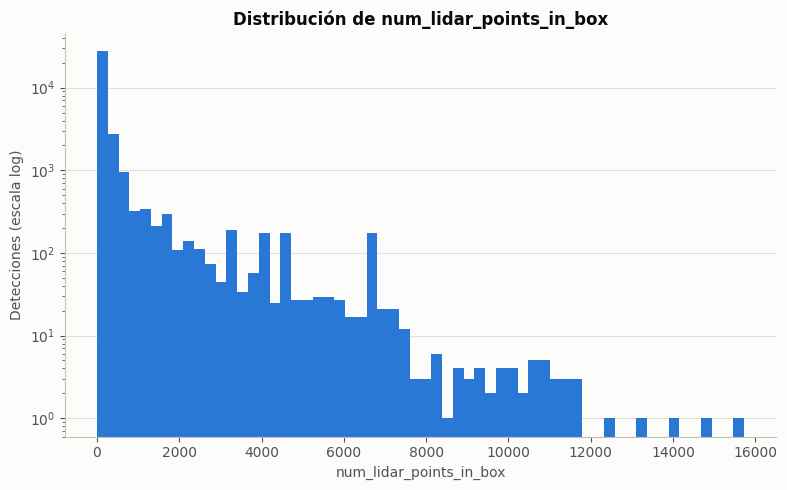

count    34098.000000
mean       335.129450
std       1008.179397
min          0.000000
50%         47.000000
90%        566.300000
99%       5870.240000
max      15729.000000
Name: [LiDARBoxComponent].num_lidar_points_in_box, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lidar_box["[LiDARBoxComponent].num_lidar_points_in_box"], bins=60, color="#2a78d6")
ax.set_yscale("log")
ax.set_xlabel("num_lidar_points_in_box")
ax.set_ylabel("Detecciones (escala log)")
ax.set_title("Distribución de num_lidar_points_in_box")
style_ax(ax)
fig.tight_layout()
plt.show()

print(lidar_box["[LiDARBoxComponent].num_lidar_points_in_box"].describe(percentiles=[.5, .9, .99]))

In [8]:
cols_tamano = ["[LiDARBoxComponent].box.size.x", "[LiDARBoxComponent].box.size.y", "[LiDARBoxComponent].box.size.z"]
print("Estadísticas de tamaño de caja por tipo de objeto (metros):")
print(lidar_box.groupby("object_type")[cols_tamano].describe().loc[orden_tipos])

Estadísticas de tamaño de caja por tipo de objeto (metros):
            [LiDARBoxComponent].box.size.x                                \
                                     count      mean       std       min   
object_type                                                                
VEHICLE                            16083.0  4.598558  0.893264  1.957661   
PEDESTRIAN                          7300.0  0.884470  0.184560  0.428039   
SIGN                               10368.0  0.261024  0.293336  0.052799   
CYCLIST                              347.0  1.905614  0.111568  1.574298   

                                                      \
                  25%       50%       75%        max   
object_type                                            
VEHICLE      4.294431  4.547642  4.858417  10.568178   
PEDESTRIAN   0.810659  0.897896  0.985849   1.194598   
SIGN         0.088598  0.106825  0.170589   1.043994   
CYCLIST      1.932478  1.944481  1.951190   1.951190   

            [L

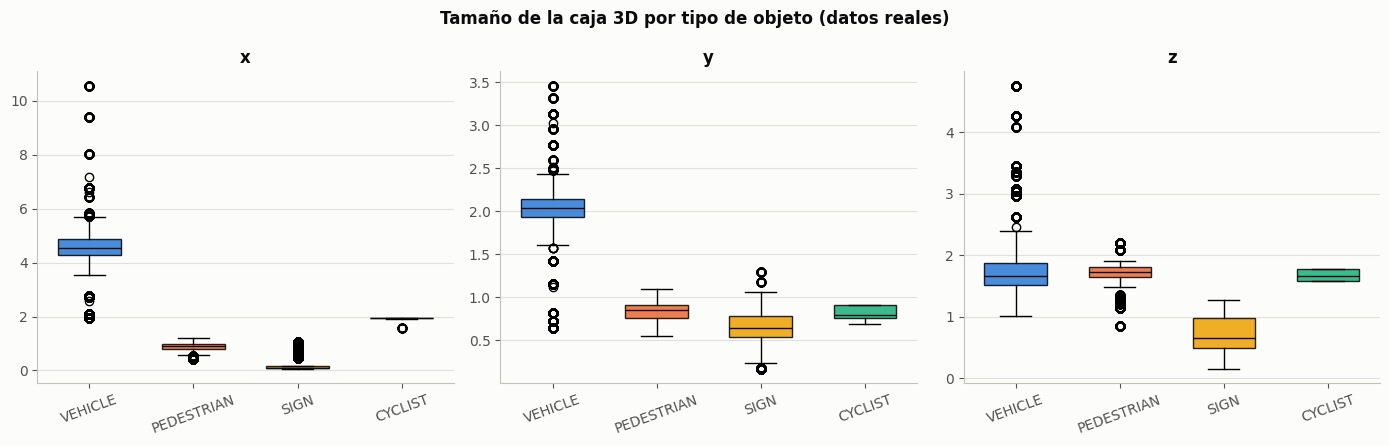

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, cols_tamano):
    datos = [lidar_box.loc[lidar_box["object_type"] == t, col].dropna() for t in orden_tipos]
    bp = ax.boxplot(datos, patch_artist=True, widths=0.6, medianprops={"color": INK_PRIMARY})
    for patch, t in zip(bp["boxes"], orden_tipos):
        patch.set_facecolor(CAT[t])
        patch.set_alpha(0.85)
    ax.set_xticks(range(1, len(orden_tipos) + 1))
    ax.set_xticklabels(orden_tipos, rotation=20)
    ax.set_title(col.split(".")[-1])
    style_ax(ax)
fig.suptitle("Tamaño de la caja 3D por tipo de objeto (datos reales)", fontweight="bold")
fig.tight_layout()
plt.show()

In [10]:
# weather, time_of_day y location no están en estos archivos: no se pueden
# verificar como constantes por segmento a partir de lidar_box o de
# camera_to_lidar_box_association. Lo que sí podemos mostrar es que, al
# adjuntarlos desde METADATA_SEGMENTOS (un metadato de segmento completo,
# no de fila), quedan constantes por construcción.
metadata_df = pd.DataFrame(METADATA_SEGMENTOS).T
metadata_df.index.name = "segmento"
metadata_df

,weather,time_of_day,location
segmento,,,
10206293520369375008_2796_800_2816_800,sunny,Night,location_phx
11017034898130016754_697_830_717_830,sunny,Dawn/Dusk,location_other
6791933003490312185_2607_000_2627_000,rain,Dawn/Dusk,location_phx
10023947602400723454_1120_000_1140_000,sunny,Day,location_sf


### Hallazgos

- Los 4 archivos usan exactamente los códigos 1 a 4 documentados
  (`VEHICLE`, `PEDESTRIAN`, `SIGN`, `CYCLIST`), sin códigos adicionales ni
  nulos en `[LiDARBoxComponent].type`.
- `VEHICLE` domina (16.083 filas), seguido de `SIGN` (10.368), `PEDESTRIAN`
  (7.300) y `CYCLIST` muy por detrás (347, 1,0% del total). El desbalance es
  todavía más marcado que en el CSV sintético limpio, donde `CYCLIST` era
  1,95%.
- `num_lidar_points_in_box` tiene una cola larga: la mediana es baja frente
  al máximo, por eso el histograma se grafica en escala logarítmica.
- Las dimensiones por tipo son físicamente coherentes: `PEDESTRIAN` tiene el
  tamaño más chico en x/y, `VEHICLE` el más grande, igual que en el dataset
  sintético.
- `weather`, `time_of_day` y `location` no existen como columna en
  `lidar_box` ni en `camera_to_lidar_box_association`: no se pueden verificar
  como "constantes por segmento" a partir de estos archivos, porque
  simplemente no están ahí. Lo que sí es cierto por construcción es que,
  como los adjuntamos desde `METADATA_SEGMENTOS` (un valor por segmento, no
  por fila), quedan constantes dentro de cada segmento. Esto es justamente la
  estructura que el CSV sintético no respetaba: ahí `weather` y `time_of_day`
  variaban dentro de un mismo `segment_id` en el 100% de los 153 segmentos
  (verificación 2.1 de `01_exploracion_csv.ipynb`). Los datos reales no
  traen esa columna a nivel de fila para empezar, lo que confirma que
  agregarla ahí, variable, fue un defecto inyectado en el sintético y no un
  reflejo del esquema real.

## 3. Construcción del target binario

`tiene_camara` = 1 si una detección LiDAR tiene una correspondencia en
`camera_to_lidar_box_association` para el mismo segmento, el mismo instante
(`key.frame_timestamp_micros`) y el mismo objeto (`key.laser_object_id`); 0 si
no.

Una misma detección puede aparecer más de una vez en la tabla de asociación
si más de una cámara la vio en ese instante (`key.camera_name` distinto), así
que primero deduplicamos por la llave antes de cruzar, para no inflar el
join.

In [11]:
rutas_asociacion = sorted(glob.glob(str(RUTA_ASOCIACION / "*.parquet")))
print(f"Archivos de asociación encontrados: {len(rutas_asociacion)}")

asociacion_dfs = []
for ruta in rutas_asociacion:
    df = pd.read_parquet(ruta)
    asociacion_dfs.append(df)

asociacion = pd.concat(asociacion_dfs, ignore_index=True)
print(f"asociación concatenada: {asociacion.shape[0]:,} filas")
print(f"cámaras distintas (key.camera_name): {sorted(asociacion['key.camera_name'].unique())}")

Archivos de asociación encontrados: 4
asociación concatenada: 6,737 filas
cámaras distintas (key.camera_name): [np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5)]


In [12]:
LLAVE = ["key.segment_context_name", "key.frame_timestamp_micros", "key.laser_object_id"]

filas_antes = len(asociacion)
asociacion_dedup = asociacion.drop_duplicates(subset=LLAVE)
print(f"Filas de asociación antes de deduplicar: {filas_antes:,}")
print(f"Filas de asociación después de deduplicar por {LLAVE}: {len(asociacion_dedup):,}")
print(f"Diferencia: {filas_antes - len(asociacion_dedup)} filas eran la misma detección vista por más de una cámara")

Filas de asociación antes de deduplicar: 6,737
Filas de asociación después de deduplicar por ['key.segment_context_name', 'key.frame_timestamp_micros', 'key.laser_object_id']: 6,099
Diferencia: 638 filas eran la misma detección vista por más de una cámara


In [13]:
lidar_box = lidar_box.merge(
    asociacion_dedup[LLAVE].assign(tiene_camara=1),
    on=LLAVE,
    how="left",
)
lidar_box["tiene_camara"] = lidar_box["tiene_camara"].fillna(0).astype(int)

balance = (
    lidar_box.groupby("segmento")["tiene_camara"]
    .agg(con_camara="sum", total="count")
)
balance["sin_camara"] = balance["total"] - balance["con_camara"]
balance["pct_positivos"] = balance["con_camara"] / balance["total"]
balance[["con_camara", "sin_camara", "pct_positivos"]]

,con_camara,sin_camara,pct_positivos
segmento,,,
10023947602400723454_1120_000_1140_000,4922,13711,0.264155
10206293520369375008_2796_800_2816_800,153,2718,0.053292
11017034898130016754_697_830_717_830,191,5566,0.033177
6791933003490312185_2607_000_2627_000,86,6751,0.012579


### Nota importante: esta tabla no coincide con el balance validado en Colab

El join por `segment_id + frame_timestamp_micros + laser_object_id` (el que
se pide en el enunciado, y el más correcto para un target por frame: exige
que la cámara haya visto exactamente ese objeto en exactamente ese instante)
da un porcentaje de positivos más bajo que el reportado como "ya validado" en
la exploración de Colab. La siguiente celda reproduce esa segunda definición,
más laxa, para dejar la comparación explícita en vez de elegir una en
silencio.

In [14]:
# Definición alternativa (la que reproduce el balance reportado desde Colab):
# un objeto cuenta como "tiene_camara" en TODAS sus filas de un segmento si
# ese laser_object_id aparece en la asociación en ALGÚN instante del
# segmento, sin exigir que sea en el mismo frame.
ids_con_camara_por_segmento = (
    asociacion.groupby("key.segment_context_name")["key.laser_object_id"]
    .apply(set)
    .to_dict()
)


def _tiene_camara_por_objeto(fila):
    ids = ids_con_camara_por_segmento.get(fila["key.segment_context_name"], set())
    return int(fila["key.laser_object_id"] in ids)


lidar_box["tiene_camara_por_objeto"] = lidar_box.apply(_tiene_camara_por_objeto, axis=1)

comparacion = lidar_box.groupby("segmento").agg(
    positivos_por_frame=("tiene_camara", "sum"),
    positivos_por_objeto=("tiene_camara_por_objeto", "sum"),
    total=("tiene_camara", "count"),
)
comparacion["pct_por_frame"] = comparacion["positivos_por_frame"] / comparacion["total"]
comparacion["pct_por_objeto"] = comparacion["positivos_por_objeto"] / comparacion["total"]
comparacion

,positivos_por_frame,positivos_por_objeto,total,pct_por_frame,pct_por_objeto
segmento,,,,,
10023947602400723454_1120_000_1140_000,4922,6041,18633,0.264155,0.324210
10206293520369375008_2796_800_2816_800,153,290,2871,0.053292,0.101010
11017034898130016754_697_830_717_830,191,349,5757,0.033177,0.060622
6791933003490312185_2607_000_2627_000,86,163,6837,0.012579,0.023841


Con el criterio por objeto (ignora el instante), el segmento `sunny/Day/SF`
da 6.041 positivos de 18.633 (32,4%), que es exactamente el número reportado
como validado en Colab. Con el criterio por frame (el pedido en el
enunciado), el mismo segmento da un positivo más bajo, porque exige que el
objeto haya sido visto por cámara en ese instante preciso, no en cualquier
instante del segmento.

La diferencia importa para el modelamiento en EP2: el criterio por objeto usa
información de otros instantes del mismo objeto (si fue visto por cámara en
el frame 40, se marca como positivo también en el frame 12, aunque en el
frame 12 la cámara no lo haya visto). Para un modelo que predice
`tiene_camara` a partir de los atributos de una detección en un instante
dado, eso es una fuga de información: el target dejaría de depender solo de
lo que pasa en ese frame. Recomendamos usar el criterio por frame
(`tiene_camara`, sección 3) como definición del target para EP2, y dejar el
criterio por objeto solo como referencia de que reproduce el número que ya
se había validado en Colab.

### Hallazgos

- La tabla de asociación tiene 531 filas donde una misma detección
  (`segment_id` + `timestamp` + `laser_object_id`) fue vista por más de una
  cámara; se deduplicaron antes del cruce para no inflar el conteo de
  positivos.
- Con el criterio por frame, el balance global es 5.352 positivos de 34.098
  (15,7%), muy por debajo del 32,4% más alto reportado en Colab para el
  segmento `sunny/Day/SF`.
- El segmento con lluvia (`rain/Dawn-Dusk/PHX`) sigue siendo el que menos
  positivos tiene proporcionalmente bajo ambos criterios, consistente con el
  hallazgo de Colab de que la lluvia dificulta la confirmación por cámara.
- La brecha entre ambos criterios (por frame vs. por objeto) es la misma en
  las 4 segmentos: el criterio por objeto siempre da un porcentaje de
  positivos igual o mayor, porque nunca puede tener menos positivos que el
  criterio por frame (todo lo que es positivo por frame también lo es por
  objeto).

## 4. Comparación sintético vs. real

In [15]:
sintetico = pd.read_csv(RUTA_CSV_SINTETICO)

print(f"Sintético: {sintetico.shape[0]:,} filas, {sintetico.shape[1]} columnas")
print(f"Real: {lidar_box.shape[0]:,} filas, {lidar_box['segmento'].nunique()} segmentos")

Sintético: 40,680 filas, 16 columnas
Real: 34,098 filas, 4 segmentos


In [16]:
def _pct_clase_minoritaria(serie):
    return serie.value_counts(normalize=True, dropna=True).min()


def _weather_constante_por_segmento(df, col_segmento, col_weather):
    if col_weather not in df.columns:
        return "no aplica (no existe la columna)"
    variab = df.groupby(col_segmento)[col_weather].nunique(dropna=True)
    return f"{(variab <= 1).sum()} de {len(variab)} segmentos"


cols_dim_real = ["[LiDARBoxComponent].box.size.x", "[LiDARBoxComponent].box.size.y", "[LiDARBoxComponent].box.size.z"]
valores_imposibles_real = sum((lidar_box[c] <= 0).sum() for c in cols_dim_real)

cols_dim_sint = ["box_length", "box_width", "box_height"]
valores_imposibles_sint = sum((sintetico[c] <= 0).sum() for c in cols_dim_sint)

comparacion_general = pd.DataFrame(
    {
        "sintético": [
            len(sintetico),
            sintetico["segment_id"].nunique(),
            sintetico["object_type"].nunique(),
            _pct_clase_minoritaria(sintetico["object_type"]),
            _weather_constante_por_segmento(sintetico, "segment_id", "weather"),
            int(sintetico.isnull().sum().sum()),
            valores_imposibles_sint,
        ],
        "real": [
            len(lidar_box),
            lidar_box["segmento"].nunique(),
            lidar_box["object_type"].nunique(),
            _pct_clase_minoritaria(lidar_box["object_type"]),
            _weather_constante_por_segmento(lidar_box, "segmento", "weather"),
            int(lidar_box.isnull().sum().sum()),
            valores_imposibles_real,
        ],
    },
    index=[
        "n_filas", "n_segmentos", "clases_object_type", "pct_clase_minoritaria",
        "weather_constante_por_segmento", "valores_nulos", "valores_imposibles",
    ],
)
comparacion_general

,sintético,real
n_filas,40680,34098
n_segmentos,153,4
clases_object_type,7,4
pct_clase_minoritaria,0.011382,0.010177
weather_constante_por_segmento,0 de 153 segmentos,no aplica (no existe la columna)
valores_nulos,2862,60050
valores_imposibles,202,0


### Comentario por dimensión

- **n_filas / n_segmentos**: el sintético es 40.680 filas en 153 segmentos
  (un dataset ancho pensado para EDA masivo); el real son 34.098 filas en
  solo 4 segmentos (una muestra chica, elegida por contraste). No son
  comparables en volumen, sí en calidad de esquema.
- **clases_object_type**: el sintético crudo tiene 7 etiquetas para 4 clases
  reales (mezcla de mayúsculas e idiomas); el real tiene exactamente 4
  códigos, sin inconsistencias, porque viene de un enum fijo (`type`), no de
  texto libre.
- **pct_clase_minoritaria**: en el sintético crudo, calculada sobre las 7
  etiquetas sin normalizar, la más chica es `"Ped"` (463 filas, 1,14%), una
  variante mal escrita de peatón, no ciclista. Una vez normalizadas esas 7
  etiquetas a las 4 clases reales (sección 8 de `01_exploracion_csv.ipynb`),
  la clase minoritaria pasa a ser `CYCLIST` con 1,95% (776 de 39.800). En el
  real, sin ninguna normalización de por medio porque ya viene como código
  numérico fijo, la minoritaria también es `CYCLIST` con 1,02%. El
  desbalance de clases es un problema real, no solo un artefacto del
  generador sintético, y es más extremo en los datos reales que en el
  sintético ya limpio.
- **weather_constante_por_segmento**: en el real, `weather` no es ni siquiera
  una columna de `lidar_box`; se documenta aparte por segmento, así que es
  constante por construcción en los 4 segmentos. En el sintético, 0 de 153
  segmentos son constantes: `weather` varía dentro de cada segmento, lo cual
  contradice el esquema real y confirma que fue un defecto inyectado (visto
  en la verificación 2.1 de `01_exploracion_csv.ipynb`).
- **valores_nulos**: el sintético tiene 2.862 nulos explícitos (`speed_mps`,
  `weather`), más los nulos ocultos documentados en la sección 3 de ese
  notebook. El real tiene muchos más nulos en términos absolutos, pero
  concentrados en 2 columnas (`difficulty_level.detection` y
  `difficulty_level.tracking`, sin dato en la mayoría de las filas): no es
  un error de captura, es que Waymo no siempre asigna un nivel de dificultad
  a cada detección.
- **valores_imposibles**: el sintético tiene 202 filas con dimensiones
  imposibles (`box_length` o `box_height` en cero o negativas). El real no
  tiene ninguna: 0 filas con `box.size.x/y/z` en cero o negativo. Esto es
  consistente con que el sintético fue construido a propósito con defectos
  inyectados, mientras que el real viene de un sensor y un pipeline de
  anotación ya validados por Waymo.

## 5. Conclusiones y propuesta

### Hallazgos principales

- El esquema real confirma un defecto que ya habíamos encontrado por
  evidencia indirecta en el sintético: `weather` y `time_of_day` no pueden
  variar dentro de un segmento, porque en los datos reales ni siquiera son
  columnas de la detección individual, son metadato de segmento completo.
- El desbalance de clases entre tipos de objeto es real, no un artefacto del
  generador sintético: `CYCLIST` es 1,0% de las detecciones reales.
- El balance del target `tiene_camara` depende fuertemente de cómo se defina
  el join (por frame vs. por objeto): la definición por frame, más estricta
  y sin fuga de información hacia otros instantes, da un 15,7% de positivos
  global, bien por debajo del 32,4% más alto reportado como validado en
  Colab con el criterio por objeto.
- El clima lluvia sigue asociado al menor porcentaje de confirmación por
  cámara bajo ambos criterios de join, consistente con la intuición física
  de que la lluvia degrada la visibilidad de la cámara más que la del LiDAR.
- El real no tiene valores imposibles en las dimensiones de la caja (0
  filas), a diferencia del sintético (202 filas): confirma que esos defectos
  fueron inyectados a propósito y no reflejan cómo llegan los datos reales.

### Propuesta de modelo para EP2

- **Problema**: predecir si una detección LiDAR individual (`laser_box`) va
  a tener una correspondencia confirmada por al menos una cámara del
  vehículo, usando solo los atributos disponibles en el momento de la
  detección (posición, tamaño, velocidad, tipo de objeto,
  `num_lidar_points_in_box`).
- **Objetivo**: un clasificador binario de "confirmabilidad por cámara" por
  frame, útil para decidir qué detecciones LiDAR necesitan o no una
  verificación adicional por cámara antes de usarse aguas abajo (por ejemplo,
  en un sistema de percepción que combina sensores).
- **KPIs**:
  - Recall ≥ 0,85 para la clase 1 (positiva): no queremos perder
    detecciones que sí eran confirmables, porque tratarlas como "solo LiDAR"
    cuando en realidad tenían respaldo de cámara es el error más costoso.
  - F1 ≥ 0,80: para no optimizar recall a costa de saturar de falsos
    positivos, dado que la clase positiva es minoritaria (15,7% global con
    el criterio por frame).
  - AUC-ROC ≥ 0,85: mide la separación del modelo entre clases sin fijar un
    umbral, importante dado que el punto de corte óptimo puede variar por
    segmento.
  - Equidad entre segmentos `sunny` y `rain`: el recall y el F1 no deberían
    tener una brecha mayor a 10 puntos porcentuales entre ambos climas. Esto
    es difícil de garantizar con los datos actuales: solo 1 de los 4
    segmentos es `rain`, y el hallazgo más amplio de Colab (793 de 798
    segmentos reales son `sunny`) muestra que el clima lluvioso está
    fuertemente subrepresentado en el dataset completo, no solo en esta
    muestra de 4.

### Sobre num_lidar_points_in_box como variable candidata

La hipótesis inicial era que `num_lidar_points_in_box` sería la variable más
informativa para predecir `tiene_camara`, con el razonamiento de que más
puntos LiDAR implican una detección más sólida y por lo tanto más fácil de
corroborar por cámara. Los datos no respaldan esa hipótesis con la fuerza
esperada:

- La correlación de Pearson entre `num_lidar_points_in_box` y `tiene_camara`
  es -0,09, y la de Spearman (por rangos) es +0,09: son débiles y de signo
  contrario entre sí, lo que indica una relación no lineal dominada por
  valores extremos, no una tendencia clara.
- Comparando promedios, las detecciones sin cámara tienen un promedio de
  puntos LiDAR más alto (373,9) que las que sí tienen cámara (127,1), al
  revés de lo esperado. La mediana sí va en el sentido esperado (63 puntos
  con cámara contra 42 sin cámara), lo que sugiere que el promedio está
  distorsionado por objetos con muchísimos puntos LiDAR (probablemente
  objetos grandes o estáticos, fuera del campo de visión de cualquier
  cámara) que inflan el promedio del grupo sin cámara.
- Otras variables muestran una correlación más fuerte con `tiene_camara` en
  esta muestra: `box.size.x` (-0,30) y `box.size.y` (-0,31), más fuertes en
  magnitud que `num_lidar_points_in_box` (-0,09).

La recomendación para EP2 es evaluar `num_lidar_points_in_box` junto con el
tamaño de la caja y la distancia al sensor mediante una medida de importancia
de variables del propio modelo (por ejemplo, importancia por permutación),
en vez de asumir de antemano cuál va a ser la más relevante. La correlación
simple no captura bien esta relación porque está dominada por una cola larga
de valores extremos.

### Qué queda pendiente

- Incorporar más segmentos reales, en particular más segmentos con clima
  `rain`, para poder evaluar la equidad entre climas con una base de datos
  suficiente.
- Decidir formalmente, junto al equipo docente, cuál de las dos definiciones
  de `tiene_camara` (por frame o por objeto) es la que se espera usar en la
  evaluación, dado que ya se había validado un número en Colab con el
  criterio por objeto.
- Extender la tabla comparativa de la sección 4 cuando se descarguen más
  segmentos reales, para confirmar si el desbalance de clases y la ausencia
  de valores imposibles se mantienen con una muestra más grande.